In [1]:
import nest_asyncio
nest_asyncio.apply()

import stan
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import proplot as plot

In [2]:


schools_code = """
data {
  int<lower=0> J;         // number of schools
  array[J] real y;              // estimated treatment effects
  array[J] real<lower=0> sigma; // standard error of effect estimates
}
parameters {
  real mu;                // population treatment effect
  real<lower=0> tau;      // standard deviation in treatment effects
  vector[J] eta;          // unscaled deviation from mu by school
}
transformed parameters {
  vector[J] theta = mu + tau * eta;        // school treatment effects
}
model {
  target += normal_lpdf(eta | 0, 1);       // prior log-density
  target += normal_lpdf(y | theta, sigma); // log-likelihood
}
"""

schools_data = {"J": 8,
                "y": [28,  8, -3,  7, -1,  1, 18, 12],
                "sigma": [15, 10, 16, 11,  9, 11, 10, 18]}

posterior = stan.build(schools_code, data=schools_data)
fit = posterior.sample(num_chains=4, num_samples=1000)
eta = fit["eta"]  # array with shape (8, 4000)
df = fit.to_frame()  # pandas `DataFrame, requires pandas

Building...



Building: found in cache, done.Messages from stanc:
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 3.3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.33 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 4.5e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.45 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.22 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.9e-05 seco

In [3]:
print(df.describe().T)

                count       mean       std           min        25%  \
parameters                                                            
lp__           4000.0 -39.565778  2.661011 -5.121517e+01 -41.206765   
accept_stat__  4000.0   0.848584  0.219675  1.010669e-81   0.822279   
stepsize__     4000.0   0.364554  0.035220  3.067646e-01   0.353541   
treedepth__    4000.0   3.293500  0.518580  1.000000e+00   3.000000   
n_leapfrog__   4000.0  11.001000  4.214076  1.000000e+00   7.000000   
divergent__    4000.0   0.000250  0.015811  0.000000e+00   0.000000   
energy__       4000.0  44.571992  3.522560  3.502015e+01  42.038808   
mu             4000.0   8.163420  5.245213 -9.495900e+00   4.900756   
tau            4000.0   6.583669  5.591486  2.203719e-02   2.453920   
eta.1          4000.0   0.405333  0.947433 -3.148354e+00  -0.211596   
eta.2          4000.0  -0.014244  0.863479 -3.363962e+00  -0.568344   
eta.3          4000.0  -0.168085  0.954559 -3.487626e+00  -0.819722   
eta.4 

CartesianAxesSubplot(index=(1, 1), number=2)

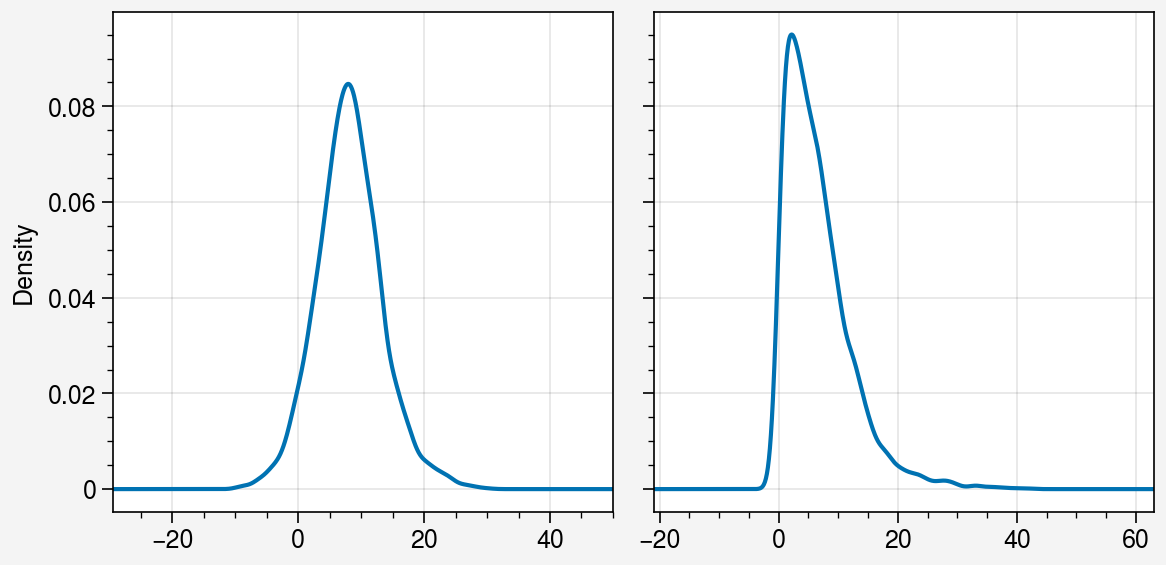

In [4]:
fig, axs = plot.subplots(ncols=2)

ax = axs[0]
df['mu'].plot.kde(ax=ax)

ax = axs[1]
df['tau'].plot.kde(ax=ax)